# Tutorial 1: Sampling

**Week 2, Day 3: Time Series**

**By Neuromatch Academy (community contribution)**

**Content Creators:** 

**Content Reviewers:** Andreas Neef, Richard Gao

**Production editors:** *to be filled in*

---

# Tutorial Objectives

*Estimated timing of tutorial: *

In this tutorial, we build the foundation for working with digitised neural
signals. Signal processing of neural or any time series data consists of two important components: 

**1. Sampling** is the discretisation of a continuous signal by measuring or recording the signal at fixed moments in time and discards everything in
between.

**2. Reconstruction** is the inverse, turning a finite sequence of samples
back into a continuous signal estimate. 


Overview:

- Sample a continuous signal at different rates 
- Implement and compare three reconstruction strategies: lollipop, linear interpolation, and sinc
- Understand the Nyquist–Shannon theorem from first principles and verify it numerically # TODO
- Identify aliasing and predict the apparent frequency of an undersampled signal

---

# Setup

## Install and import feedback gadget


In [91]:
# @title Install and import feedback gadget
!pip3 install vibecheck datatops --quiet
from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()
feedback_prefix = "W2D2_T3S1"

In [92]:
# @title Imports
import numpy as np
from numpy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from ipywidgets import interact
import warnings
warnings.filterwarnings('ignore')

## Figure settings

In [93]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [94]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display, HTML

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")
plt.rcParams.update({'figure.facecolor' : 'white',
                     'axes.facecolor'   : 'white',
                     'savefig.facecolor': 'white'})
display(HTML("""
<style>
  .widget-output { background: white !important;
                   border: none !important; padding: 0 !important; }
</style>"""))

# Helper functions

---

# Section 1: Subsampling

*Estimated timing to here from start of tutorial: min*


## Video 1: Subsampling


In [95]:
from IPython.display import HTML
HTML("<div style='background:#eee;padding:1em;border-radius:6px;'>"
     "<b>Video 1 placeholder.</b> Topics: Subsampling intro from true signals; sampling frequency"
     "</div>")

In [96]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_1_Subsampling")


## What is subsampling?

Neural processes unfold across a wide range of timescales, sharp-wave ripples last tens of milliseconds while slow cortical rhythms evolve over seconds. The recording system must be fast enough to capture the process of interest, yet storing every voltage measurement at the highest possible rate is neither practical nor necessary.

The idea behind sampling is to reduce the data quantity of an (analog) signal or to be able to record the signal in a way that allows one to reconstruct the signal afterwards. The frequency at which the device records measurements is called sampling frequency, $f_s$. Your recording device therefore saves one sample every $1/f_s$ seconds, a process called **Sampling** .

Mathematically, if the true signal is $x(t)$ and the sampling interval
is $T = 1/f_s$, then what your device records is:

$$x[n] = x(nT), \qquad n = 0, 1, 2, \ldots$$

## Coding Exercise 1: Implement subsampling


Complete the function below. Given the full dense signal and a target
sampling rate, return the times and values of the sampled points.

**Hint:** compute the step size as `round(FS_TRUE / fs)` and use
`np.arange` to pick every $k$-th index.

In [121]:
# @title True Signal Generation — run this cell

FS_TRUE   = 10_000.0   # dense axis, treated as continuous
F_SIGNAL  = 5.0        # Hz — sine wave frequency
DURATION  = 1.0        # seconds — displayed window
TOTAL_DUR = 100.0      # seconds — full context for sinc reconstruction

# ── sine signal ──────────────────────────────────────────────
_N          = int(FS_TRUE * TOTAL_DUR)
_t_total    = np.linspace(0, TOTAL_DUR, _N, endpoint=False)
_sig_sine   = np.sin(2 * np.pi * F_SIGNAL * _t_total)

_start_t    = (TOTAL_DUR - DURATION) / 2
_mask       = (_t_total >= _start_t) & (_t_total < _start_t + DURATION)
t_eval      = _t_total[_mask]          # total-time axis — used in sinc, never shifted
t_plot      = t_eval - _start_t        # 0–1 s axis — used only for plotting
sig_true    = _sig_sine[_mask]         # ground truth: same array as _sig_sine

# ── transient evoked signal ───────────────────────────────────
F_TRANSIENT  = 60.0    # Hz — carrier frequency of the transient
_center      = TOTAL_DUR / 2
_sigma       = 0.05  
_envelope    = np.exp(-((_t_total - _center)**2) / (2 * _sigma**2))
_sig_trans   = _envelope * np.sin(2 * np.pi * F_TRANSIENT * _t_total)

sig_transient = _sig_trans[_mask]

print(f'Sine signal:      {len(sig_true)} samples in display window')
print(f'Transient signal: peak = {sig_transient.max():.3f}, '
      f'carrier = {F_TRANSIENT} Hz')

Sine signal:      10000 samples in display window
Transient signal: peak = 0.996, carrier = 60.0 Hz


In [98]:
# @markdown Execute after completing the function

def subsample(t_total, sig_total, fs):
    """Subsample a dense signal at a target rate.

    Parameters
    ----------
    t_total   : (N,) full time axis at FS_TRUE resolution
    sig_total : (N,) full signal
    fs        : float, target sampling rate in Hz

    Returns
    -------
    t_samp : (M,) sample times
    y_samp : (M,) sample values
    """
    ##############################################################################
    # TODO: compute step size and return every step-th sample
    step   = max(1, int(round(FS_TRUE / fs))) # make it max(1, int(round(...)))
    idx    = np.arange(0, len(t_total), step) # make it np.arange(0, len(t_total), ...)
    return t_total[idx], sig_total[idx]
    ##############################################################################


# --- test ---
t_samp, y_samp = subsample(_t_total, _sig_sine, fs=20)
print(f'fs=20 Hz → {len(t_samp)} total samples, '
      f'step = {round(FS_TRUE/20)} samples')
assert len(t_samp) == 2000, 'Expected 2000 samples for fs=20 over 100 s'
print('Test passed ✓')
print('')

fs=20 Hz → 2000 total samples, step = 500 samples
Test passed ✓



[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D3_LinearSystems/solutions/W2D3_Tutorial1_Solution_lti.py)


### We have 100 s of data sampled at 20 Hz from an underlying simulated ground truth signal with 10000 Hz

In [99]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_1_LTI")


---

# Section 2: Reconstruction

*Estimated timing to here from start of tutorial: min*


In [100]:
# @title Video 2: Convolution as flip-and-slide
from IPython.display import HTML
HTML('<div style="background:#eee;padding:1em;border-radius:6px;">'
     '<b>Video 2 placeholder.</b> Topics: Reconstruction strategies: straight lines, lollipop and sinc'
     '</div>')

In [101]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_2_Convolution")

## Reconstruction strategies

Once we have discrete samples $x[n]$, you need to estimate the
signal at times between samples. There are three strategies:


**Lollipop** : plot only the sample values as vertical stems.This
shows exactly what was measured and all information between the samples is not considered.


**Linear interpolation** : connect adjacent samples with straight lines:

Use `np.interp(t_eval, t_samp, y_samp)`.

**Sinc interpolation** : we will look at this later after understanding the limitations of the other two.

## Coding Exercise 2: Implement linear interpolation

In [102]:

def get_one_second_signal_to_visualize(t_samp, y_samp, start_t):
    """Return sample positions shifted to the 0–1 s plot axis.

    Parameters
    ----------
    t_samp  : (M,) sample times on the total-time axis
    y_samp  : (M,) sample values
    start_t : float, offset of the display window

    Returns
    -------
    t_vis : visible sample times shifted to 0–1 s
    y_vis : corresponding sample values
    """
    ##############################################################################
    in_win = (t_samp >= start_t) & (t_samp < start_t + DURATION)
    t_vis  = t_samp[in_win] - start_t
    y_vis  = y_samp[in_win]
    return t_vis, y_vis
    ##############################################################################


In [103]:
# @title Helper: plot_reconstruction — run this cell

def plot_reconstruction(fs, mode):
    t_samp, y_samp = subsample(_t_total, _sig_sine, fs)
    t_v, y_v       = get_one_second_signal_to_visualize(t_samp, y_samp, _start_t)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6),
                             constrained_layout=True, sharex=True)
    fig.set_facecolor('white')

    # top: true + samples
    ax = axes[0]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.8,
            alpha=0.85, label='True signal', zorder=2)
    ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
            zorder=4, label=f'Samples ({len(t_v)} in window)')
    ax.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
           title=f'True signal and samples  (fs = {fs} Hz)')
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)

    # bottom: reconstruction
    ax = axes[1]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.4,
            alpha=0.25, label='True signal (reference)', zorder=1)
    ##############################################################################
    #TODO: fill in the lines to plot the reconstruction according to the selected mode
    ##############################################################################
    
    if mode == 'lollipop':
        ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
                label='Lollipop', zorder=4)
        ax.vlines(t_v, 0, y_v, color='#d62728', lw=1.3, alpha=0.75, zorder=3) ##  make it  ax.vlines(t_v, ..., ..., color='#d62728', lw=1.3, alpha=0.75, zorder=3)
        
        title = 'Lollipop'

    elif mode == 'linear':
   
        ax.plot(t_v, y_v, '-o', color='#d62728', markersize=4, zorder=4) ## make it ax.plot(t_v, ... , ... , color='#d62728', markersize=4, zorder=4)
        title = 'Linear - straight lines between samples'

    else:
        print(f'Unknown mode: {mode}')

    ax.set(xlabel='Time (s)', ylabel='Amplitude',
           ylim=(-1.25, 1.25), title=title)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)
    plt.show()
    
# @markdown Execute to compare reconstruction strategies

@widgets.interact(
   
    mode = widgets.RadioButtons(
               options=[('Lollipop',                'lollipop'),
                        ('Straight-line connectors', 'linear'),
                        #('Sinc reconstruction',      'sinc')
                        ],
               value='lollipop',
               description='Method:',
               style={'description_width': '70px'})
)
def visualize_reconstruction( mode='lollipop'):
    plot_reconstruction(fs=15, mode = mode)

interactive(children=(RadioButtons(description='Method:', options=(('Lollipop', 'lollipop'), ('Straight-line c…

## Think! 1: Are these optimal recosntruction strategies?

You have now seen two ways to represent the sampled signal.

**Question 1** : Neither the lollipop nor the straight-line connector
is an optimal reconstruction. What is missing from each?

\
To remove later as solution: \
'''
- The lollipop tells you the exact value at each sample instant but
  makes no claim about what happens in between. Is that a valid
  representation of the signal, or does it discard information you
  already have?

- The straight-line connector fills in the gaps, but assumes the signal
  changes at a constant rate between any two adjacent samples. IS it optimal for neural processes?
'''
\
\

**Question 2** : A straight line is one way to connect two sample
points smoothly. But there are infinitely many smooth curves that pass
through the same two points. 


### The sinc function

A straight line is one way to connect two sample
points smoothly but doesn't capture the true underlying signal. Also, there are infinitely many smooth curves that pass through the same two points. 

We need a function that has a value of 1 at exactly one moment in time (which can be scaled according to our sampled data point's amplitude), and fades away on both sides.

The sinc function has exactly this shape:

$$\operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

It oscillates like a sine wave but with an amplitude that decays as you
move away from the centre. At $u = 0$ the amplitude is 1 which is the peak.
As $|u|$ grows the oscillations shrink, approaching zero. Crucially, it
hits zero at every nonzero integer at $u = \pm 1, \pm 2, \pm 3,
\ldots$ .

Think of it as a sine wave that has been divided by a steadily growing
number the further from the centre, the more the oscillation is
suppressed.

## Coding Exercise 3: Sinc function


Before using sinc reconstruction, implement the sinc function yourself
from its definition:

$$\operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

At $u = 0$ the expression $0/0$ is indeterminate. Handle this as a
special case, the limit is 1, so set $\operatorname{sinc}(0) = 1$.

**Hint:** use `np.sin`, `np.pi`, and `np.where` to handle the
$u = 0$ case without dividing by zero.

All tests passed ✓


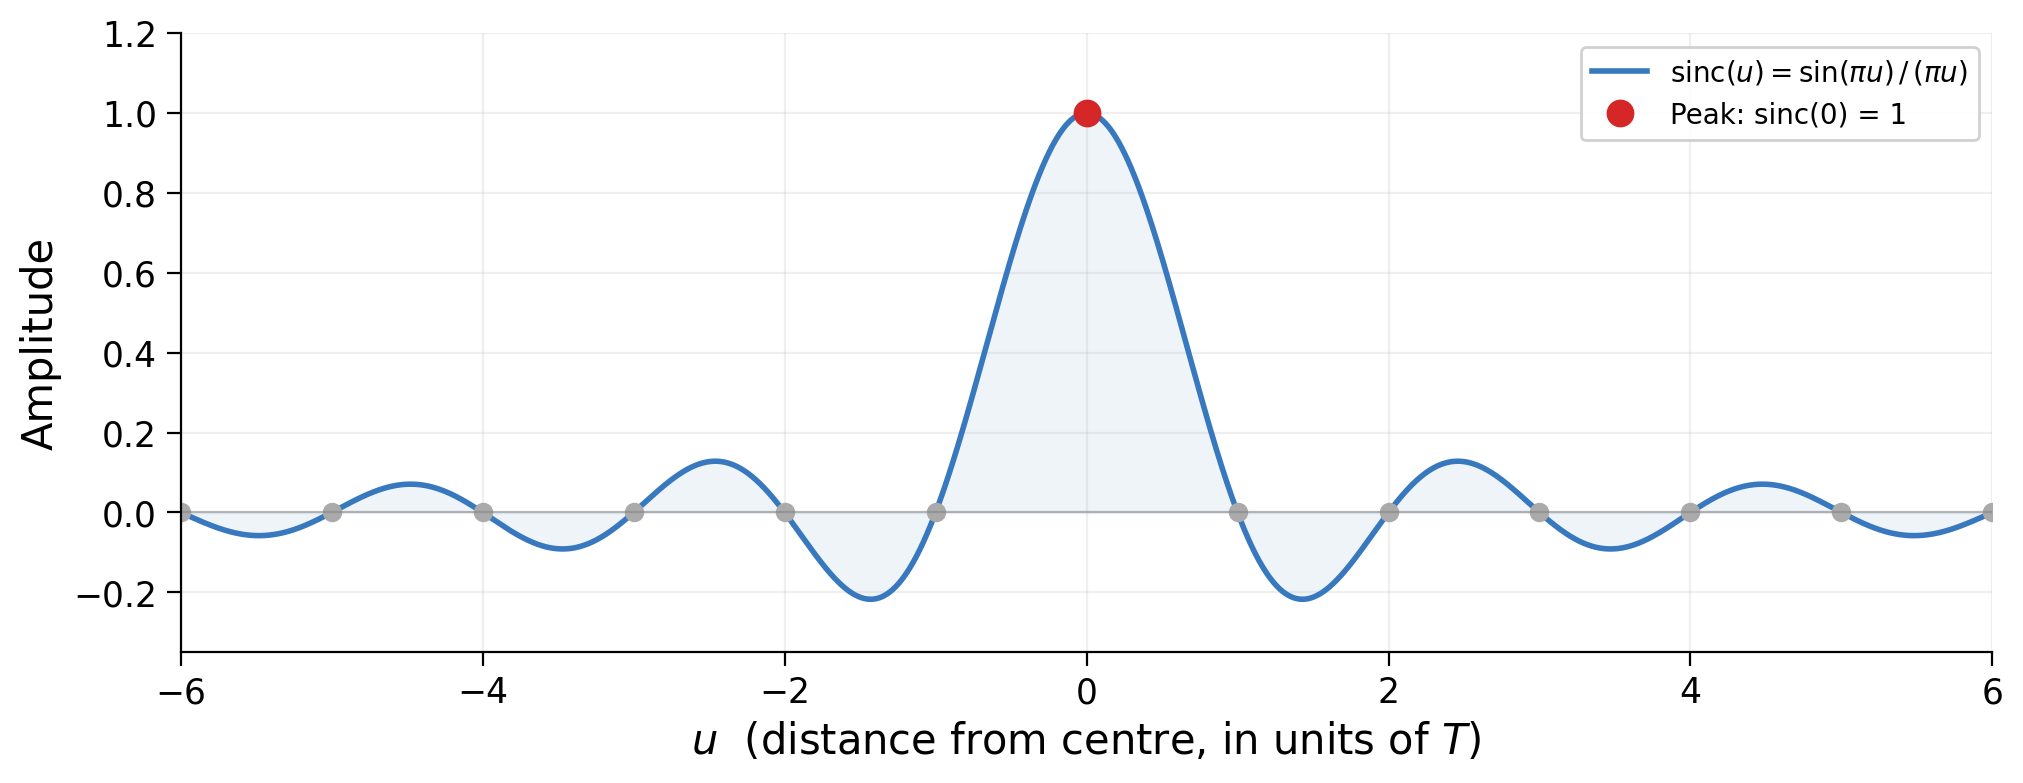

In [104]:
# @markdown Execute after completing the function

def sinc(u):
    """Evaluate the sinc function at u.

    Parameters
    ----------
    u : float or np.ndarray
        Argument(s) to evaluate. Units are normalised sample intervals.

    Returns
    -------
    float or np.ndarray
        sinc(u) = sin(pi * u) / (pi * u), with sinc(0) = 1.
    """
    u = np.asarray(u, dtype=float)

    ##############################################################################
    # TODO: compute sin(pi * u) / (pi * u) and handle the u=0 case
    # Hint: np.where(condition, value_if_true, value_if_false)
    denom = np.pi * u
    y     = np.where(u == 0, 1.0, np.sin(denom) / denom) ## make it np.where(u == ..., 1.0, np.sin(...) / ...)
    return y
    ##############################################################################


# ── test ─────────────────────────────────────────────────────
assert np.isclose(sinc(0),    1.0),  'sinc(0) should be 1'
assert np.isclose(sinc(1),    0.0),  'sinc(1) should be 0'
assert np.isclose(sinc(-1),   0.0),  'sinc(-1) should be 0'
assert np.isclose(sinc(0.5),  2/np.pi), 'sinc(0.5) should be 2/pi'
print('All tests passed ✓')

# ── visualise ─────────────────────────────────────────────────
u        = np.linspace(-6, 6, 10_000)
y        = sinc(u)
integers = np.arange(-6, 7)

fig, ax = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
fig.set_facecolor('white')

ax.plot(u, y, color='#3778bf', lw=2.0, zorder=2,
        label=r'$\mathrm{sinc}(u) = \sin(\pi u)\,/\,(\pi u)$')
ax.fill_between(u, y, alpha=0.08, color='#3778bf')

# zero crossings at nonzero integers
ax.stem(integers[integers != 0],
        sinc(integers[integers != 0]),
        linefmt='#aaaaaa', markerfmt='o', basefmt='none')

# peak
ax.plot(0, 1, 'o', color='#d62728', markersize=9,
        zorder=5, label='Peak: sinc(0) = 1')

ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax.set(xlabel='$u$  (distance from centre, in units of $T$)',
       ylabel='Amplitude',
       xlim=(-6, 6), ylim=(-0.35, 1.2))
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.20)
plt.show()

## Interpolating using sinc function

To reconstruct the signal at any time point $t$, scale each sinc kernel
by the amplitude of its corresponding sample $x[n]$ and sum the
contributions from all samples:

$$\hat{x}(t) = \sum_{n} x[n] \cdot \operatorname{sinc}\!\left(\frac{t - nT}{T}\right)$$

The argument $\frac{t - nT}{T}$ measures how far the evaluation point
$t$ is from sample $n$, in units of the sampling interval $T$. Each sinc peaks at its own sample and is zero at all others.

In [105]:

def reconstruct_sinc(t_samp, y_samp,t_eval):
    """
    Whittaker–Shannon sinc reconstruction.

    Uses the nearest n_terms samples on each side of every evaluation
    point — sinc tails beyond that are below one display pixel.

    Parameters
    ----------
    t_samp  : (M,) sample times (total-time axis, full 100 s context)
    y_samp  : (M,) sample values
    t_eval  : (N,) evaluation times (total-time axis)
    n_terms : int, half-width of the local sinc window

    Returns
    -------
    y_hat : (N,) reconstructed signal
    """
    ##############################################################
   
    T = t_samp[1] - t_samp[0]
    # generate a denser grid than the samples, to get the intermediate values
    y_hat = np.zeros(len(t_eval))
    for i, t in enumerate(t_eval):
        diff = (t - t_samp) / T ## make it (t - ...) / ...
        y_hat[i] = (y_samp * sinc(diff)).sum()  ## make it (y_samp * sinc(...)).sum()
    return t_eval, y_hat
    #############################################################


# --- test ---
t_samp, y_samp = subsample(_t_total, _sig_sine, fs=20)
t_eval, y_sinc  = reconstruct_sinc(t_samp, y_samp,t_eval )

#assert y_sinc.shape == sig_true.shape, 'Sinc output shape mismatch'
print('All reconstruction tests passed ✓')

All reconstruction tests passed ✓


## Interactive Demo 2: Comparing reconstruction strategies

Use the interactive demo below to compare the three strategies at a
**fixed** sampling rate and signal. The true signal is a $5$ Hz sine
wave sampled from a $100$-second context window.


In [ ]:
# @title Helper: plot_reconstruction — run this cell

def plot_reconstruction(fs, mode , t_eval):
    t_samp, y_samp = subsample(_t_total, _sig_sine, fs)
    t_v, y_v       = get_one_second_signal_to_visualize(t_samp, y_samp, _start_t)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6),
                             constrained_layout=True, sharex=True)
    fig.set_facecolor('white')

    # top: true + samples
    ax = axes[0]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.8,
            alpha=0.85, label='True signal', zorder=2)
    ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
            zorder=4, label=f'Samples ({len(t_v)} in window)')
    ax.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
           title=f'True signal and samples  (fs = {fs} Hz)')
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)

    # bottom: reconstruction
    ax = axes[1]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.4,
            alpha=0.25, label='True signal (reference)', zorder=1)

    if mode == 'lollipop':
        ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
                label='Lollipop', zorder=4)
        ax.vlines(t_v, 0, y_v, color='#d62728', lw=1.3, alpha=0.75, zorder=3) ##  make it  ax.vlines(t_v, ..., ..., color='#d62728', lw=1.3, alpha=0.75, zorder=3)
        
        title = 'Lollipop'

    elif mode == 'linear':
   
        ax.plot(t_v, y_v, '-o', color='#d62728', markersize=4, zorder=4) ## make it ax.plot(t_v, ... , ... , color='#d62728', markersize=4, zorder=4)
        title = 'Linear - straight lines between samples'


    else:
        t_eval, y_sinc = reconstruct_sinc(t_samp, y_samp,t_eval)
        t_v1, y_v1       = get_one_second_signal_to_visualize(t_eval, y_sinc, _start_t)
        ax.plot(t_v1,y_v1, color='#9467bd', lw=1.8,label='Sinc reconstruction', zorder=3)
        
        ax.plot(t_v, y_v, 'o', color='#d62728', markersize=4, zorder=4)
        title = 'Sinc — Whittaker–Shannon reconstruction'

    ax.set(xlabel='Time (s)', ylabel='Amplitude',
           ylim=(-1.25, 1.25), title=title)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)
    plt.show()

# @markdown Execute to compare reconstruction strategies

@widgets.interact(
    #fs   = widgets.IntSlider(value=15, min=11, max=80, step=1,
    #                         description='fs (Hz):',
    #                         style={'description_width': '70px'},
    #                         layout=widgets.Layout(width='480px')),
    mode = widgets.RadioButtons(
               options=[('Lollipop',                'lollipop'),
                        ('Straight-line connectors', 'linear'),
                        ('Sinc reconstruction',      'sinc')
                        ],
               value='lollipop',
               description='Method:',
               style={'description_width': '70px'})
)
def visualize_reconstruction(mode='lollipop'):
    plot_reconstruction(fs = 15, mode = mode , t_eval = t_eval)

interactive(children=(RadioButtons(description='Method:', options=(('Lollipop', 'lollipop'), ('Straight-line c…

---

# Section 3: Effect of sampling rate

*Estimated timing to here from start of tutorial: min*



You have confirmed that sinc reconstruction is optimal among the three reconstruction strategies. Now the question
is: **how low can the sampling rate go before even sinc fails?**


## Interactive Demo 3: Find the frequency at which reconstruction fails


The demo below fixes sinc as the reconstruction method and lets you
vary $f_s$. There are two signals to explore:

1. **Sine wave** : a pure $5$ Hz oscillation. Watch the sinc
   reconstruction degrade as you approach then cross a critical threshold.

2. **Transient response** : a brief oscillatory burst (like a
   stimulus-locked high-gamma response). The lower subplot shows its
   **power spectrum** 
**Your task:** for each signal, find the lowest $f_s$ at which sinc
reconstruction still accurately recovers the signal. Write those two
numbers down before reading the next Section.

In [108]:
# @markdown Execute after completing the function

def reconstruction_error(sig_true, sig_recon):
    """Compute RMSE between true and reconstructed signal.

    Parameters
    ----------
    sig_true  : (N,) ground truth signal
    sig_recon : (N,) reconstructed signal

    Returns
    -------
    float : root mean square error
    """
    ##############################################################################
    return np.sqrt(np.mean((sig_true - sig_recon) ** 2))
    ##############################################################################


In [136]:
# @title Helper: plot_sinc_explorer — run this cell

def plot_sinc_explorer(fs, signal_type , t_eval):
    if signal_type == 'sine':
        sig_full  = _sig_sine
        sig_disp  = sig_true
        f_label   = f'{F_SIGNAL} Hz sine'
    else:
        sig_full  = _sig_trans
        sig_disp  = sig_transient

        f_label   = f'Transient signal with maximum power upto 72 Hz'

    t_samp, y_samp = subsample(_t_total, sig_full, fs)
    t_eval, y_sinc = reconstruct_sinc(t_samp, y_samp, t_eval)
    t_v, y_v       =  get_one_second_signal_to_visualize(t_samp, y_samp, _start_t)
    rmse           = reconstruction_error(sig_disp, y_sinc)

    fig = plt.figure(figsize=(10, 7), constrained_layout=True)
    fig.set_facecolor('white')
    gs  = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[2, 2, 1.2])

    # ── top: true + samples ───────────────────────────────────
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(t_plot, sig_disp, color='#3778bf', lw=1.8,
             alpha=0.85, label='True signal', zorder=2)
    ax0.plot(t_v, y_v, 'o', color='#d62728', markersize=5,
             zorder=4, label=f'Samples ({len(t_v)})')
    ax0.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
            title=f'{f_label}')
    ax0.legend(fontsize=9, loc='upper right', framealpha=0.9)
    ax0.grid(True, alpha=0.20)

    # ── middle: sinc reconstruction ──────────────────────────
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax1.plot(t_plot, sig_disp, color='#3778bf', lw=1.4,
             alpha=0.25, label='True signal (reference)', zorder=1)
    ax1.plot(t_plot, y_sinc, color='#9467bd', lw=1.8,
             label='Sinc reconstruction', zorder=3)
    ax1.plot(t_v, y_v, 'o', color='#d62728', markersize=4, zorder=4)
    ax1.text(0.99, 0.95, f'RMSE = {rmse:.4f}',
             transform=ax1.transAxes, fontsize=10,
             ha='right', va='top',
             color='#27ae60' if rmse < 0.05 else '#c0392b',
             fontweight='bold')
    ax1.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
            title='Sinc reconstruction')
    ax1.legend(fontsize=9, loc='upper right', framealpha=0.9)
    ax1.grid(True, alpha=0.20)
    print(f'RMSE of sinc reconstruction: {rmse:.4f}')

    # ── bottom: power spectrum ───────────────────────────────
    #ax2 = fig.add_subplot(gs[2])
    #freqs = rfftfreq(len(sig_disp), 1.0 / FS_TRUE)
    #power = np.abs(rfft(sig_disp))**2
    #power_r = np.abs(rfft(y_sinc))**2
    #ax2.semilogy(freqs, power,   color='#3778bf', lw=1.4,
    #             alpha=0.6, label='True')
    #ax2.semilogy(freqs, power_r, color='#9467bd', lw=1.4,
    #             alpha=0.8, label='Reconstructed', ls='--')
    #ax2.axvline(fs / 2, color='#e74c3c', lw=1.3, ls='--',
    #            label=f'Nyquist = {fs/2:.0f} Hz')
    #ax2.set(xlabel='Frequency (Hz)', ylabel='Power',
    #        xlim=(0, min(FS_TRUE/2, 200)),
    #        title='Power spectrum')
    #if signal_type == 'sine':
    #        ax2.set_xlim((0,20))
    #else:
    #        ax2.set_xlim((0,300))
    #ax2.legend(fontsize=9, loc='upper right', framealpha=0.9)
    #ax2.grid(True, alpha=0.20)
    plt.show()
    
# @markdown Execute to explore the effect of sampling rate

@widgets.interact(
    fs = widgets.IntSlider(value=30, min=5, max=500, step=1,
                           description='fs (Hz):',
                           style={'description_width': '70px'},
                           layout=widgets.Layout(width='500px')),
    signal_type = widgets.RadioButtons(
                      options=[('Sine wave',          'sine'),
                               ('Transient response', 'transient')],
                      value='sine',
                      description='Signal:',
                      style={'description_width': '70px'})
)
def visualize_sinc_explorer(fs=30, signal_type='sine'):
    plot_sinc_explorer(fs, signal_type , t_eval)

interactive(children=(IntSlider(value=30, description='fs (Hz):', layout=Layout(width='500px'), max=500, min=5…

## The Nyquist–Shannon sampling theorem


In [128]:
# @title Video 3: The Nyquist–Shannon sampling theorem
from IPython.display import HTML
HTML('<div style="background:#eee;padding:1em;border-radius:6px;">'
     '<b>Video 4 placeholder.</b> Topics: The Nyquist–Shannon sampling theorem.'
     '</div>')


The threshold below which reconstruction fails is given by the follwoing theorem:

> **Nyquist–Shannon sampling theorem:** A continuous bandlimited signal
> with highest frequency $f_{\max}$ can be perfectly reconstructed from
> its samples if and only if the sampling rate satisfies:
>
> $$\boxed{f_s > 2\, f_{\max}}$$

The value $f_N = f_s / 2$ is called the **Nyquist frequency**, the
highest frequency your recording system can faithfully capture.

For the two signals you explored:

| Signal | $f_{\max}$ | Minimum $f_s$ |
|---|---|---|
| Sine wave | $5$ Hz | $> 10$ Hz |
| Transient response | $72$ Hz | $> 144$ Hz |

Does that match the thresholds you found with the slider?


---

# Section 4: Aliasing

*Estimated timing to here from start of tutorial: min*



When $f_s < 2 f_{\text{signal}}$, the signal **reappears at a wrong slower frequency**. This is aliasing.

### Why does aliasing happen?

A sampler only records one number per interval $1/f_s$. If the signal
oscillates faster than the sampler can track, successive samples
accidentally trace out a *slower* wave that was never in the data.
The sampler cannot tell the two apart, they are identical at every
sample point.

### What frequency does the alias appear at?

Each integer multiple of $f_s$ acts like a mirror. The alias lands at
the distance from $f_{\text{true signal}}$ to its nearest such mirror:

$$f_{\text{alias}} = \left| f_{\text{true signal}} - \operatorname{round}
\!\left(\frac{f_{\text{true signal}}}{f_s}\right) \cdot f_s \right|$$

### Worked example

A $30$ Hz true signal sampled at $f_s = 40$ Hz (Nyquist $= 20$ Hz):

1. Nearest mirror: $\operatorname{round}(30/40) \times 40 = 1 \times 40 = 40$ Hz
2. Distance to mirror: $|30 - 40| = 10$ Hz

The $30$ Hz true oscillation appears as $10$ Hz oscillation
in your sampled data.

## Coding Exercise 4: Compute Aliased Frequency



In [137]:
# @markdown Execute after completing the function

def compute_aliased_frequency(signal_freq, sampling_rate):
    """Compute the apparent frequency after aliasing.

    Parameters
    ----------
    signal_freq   : float, true signal frequency (Hz)
    sampling_rate : float, sampling rate (Hz)

    Returns
    -------
    float : apparent frequency (Hz). Returns signal_freq if no aliasing.
    """
    if sampling_rate >= 2 * signal_freq:
        return signal_freq   # above Nyquist — no aliasing

    ##############################################################################
    f_alias = abs(signal_freq - round(signal_freq / sampling_rate) * sampling_rate)
    return f_alias
    ##############################################################################


# --- test ---
cases = [(5, 8, 3.0), (5, 7, 2.0), (30, 40, 10.0), (5, 20, 5.0)]
for f, fs, expected in cases:
    result = compute_aliased_frequency(f, fs)
    status = '✓' if abs(result - expected) < 1e-9 else '✗'
    print(f'{status}  f={f} Hz, fs={fs} Hz → alias={result:.1f} Hz '
          f'(expected {expected:.1f} Hz)')

✓  f=5 Hz, fs=8 Hz → alias=3.0 Hz (expected 3.0 Hz)
✓  f=5 Hz, fs=7 Hz → alias=2.0 Hz (expected 2.0 Hz)
✓  f=30 Hz, fs=40 Hz → alias=10.0 Hz (expected 10.0 Hz)
✓  f=5 Hz, fs=20 Hz → alias=5.0 Hz (expected 5.0 Hz)


## Interactive Demo 4: Visualize aliasing frequency

In [139]:
def plot_aliasing(signal_freq, fs):

    # ── build 100s context signal ─────────────────────────────
    N_loc        = int(FS_TRUE * TOTAL_DUR)
    t_total_loc  = np.linspace(0, TOTAL_DUR, N_loc, endpoint=False)
    sig_loc      = np.sin(2 * np.pi * signal_freq * t_total_loc)

    start_t_loc  = (TOTAL_DUR - DURATION) / 2
    mask_loc     = (t_total_loc >= start_t_loc) & (t_total_loc < start_t_loc + DURATION)
    t_eval_loc   = t_total_loc[mask_loc]
    t_plot_loc   = t_eval_loc - start_t_loc
    sig_true_loc = sig_loc[mask_loc]

    # ── subsample ─────────────────────────────────────────────
    t_samp_loc, y_samp_loc = subsample(t_total_loc, sig_loc, fs)
    in_win  = (t_samp_loc >= start_t_loc) & (t_samp_loc < start_t_loc + DURATION)
    t_v_loc = t_samp_loc[in_win] - start_t_loc
    y_v_loc = y_samp_loc[in_win]

    # ── sinc reconstruct ──────────────────────────────────────
    t_eval, y_sinc = reconstruct_sinc(t_samp_loc, y_samp_loc, t_eval_loc)

    # ── aliasing info ─────────────────────────────────────────
    nyquist     = fs / 2
    aliased     = signal_freq > nyquist
    f_alias     = compute_aliased_frequency(signal_freq, fs)
    recon_color = '#c0392b' if aliased else '#27ae60'
    status      = (f'⚠  Aliasing — {signal_freq} Hz appears as {f_alias:.1f} Hz'
                   if aliased else
                   f'✓  No aliasing  (Nyquist = {nyquist:.0f} Hz > {signal_freq} Hz)')

    # ── plot ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    fig.set_facecolor('white')

    ax.plot(t_plot_loc, sig_true_loc,
            color='#3778bf', lw=1.8, alpha=0.85,
            label=f'True signal ({signal_freq} Hz)', zorder=2)
    ax.plot(t_plot_loc, y_sinc,
            color=recon_color, lw=1.8,
            label='Sinc reconstruction', zorder=3)
    ax.plot(t_v_loc, y_v_loc, 'o',
            color='#d62728', markersize=6,
            label=f'Samples ({len(t_v_loc)})', zorder=5)

    ax.text(0.99, 0.97, status,
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color=recon_color, ha='right', va='top')
    ax.set(xlabel='Time (s)', ylabel='Amplitude',
           ylim=(-1.25, 1.25),
           title=f'Signal = {signal_freq} Hz   '
                 f'fs = {fs} Hz   '
                 f'Nyquist = {nyquist:.0f} Hz')
    ax.legend(fontsize=9, framealpha=0.9, loc='upper left')
    ax.grid(True, alpha=0.20)
    plt.show()
    

# @markdown Execute to visualise aliasing

@widgets.interact(
    signal_freq = widgets.IntSlider(value=5, min=2, max=10, step=1,
                                    description='Signal (Hz):',
                                    style={'description_width': '100px'},
                                    layout=widgets.Layout(width='480px')),
    fs          = widgets.IntSlider(value=40, min=3, max=50, step=1,
                                    description='fs (Hz):',
                                    style={'description_width': '100px'},
                                    layout=widgets.Layout(width='480px'))
)
def visualize_aliasing(signal_freq=5, fs=40):
    plot_aliasing(signal_freq, fs)

interactive(children=(IntSlider(value=5, description='Signal (Hz):', layout=Layout(width='480px'), max=10, min…

---

# Summary

*Estimated timing of tutorial: to be filled in*

---

**Subsampling**:

A continuous signal $x(t)$ is reduced to a discrete sequence by recording its value at regular intervals:

$$x[n] = x(nT), \qquad T = \frac{1}{f_s}$$

- **Sampling frequency** $f_s$ (Hz) sets how many measurements are taken per second.
- The step size in samples is $k = \text{round}(f_{s,\text{true}} / f_s)$; every $k$-th index of the dense array is retained.
- Higher $f_s$ preserves more detail but increases data volume and storage cost.

---

**Reconstruction**

Given discrete samples $x[n]$, three strategies estimate the signal between sample points:

| Strategy | How it works | Limitation |
|---|---|---|
| **Lollipop** | Show only sample values as vertical stems | No information about between-sample values |
| **Linear interpolation** | Connect adjacent samples with straight lines | Assumes constant rate of change; distorts curved signals |
| **Sinc reconstruction** | Sum scaled sinc kernels centred at each sample | Optimal — requires samples above Nyquist rate |

**Sinc interpolation formula:**

$$\hat{x}(t) = \sum_{n} x[n] \cdot \operatorname{sinc}\!\left(\frac{t - nT}{T}\right), \qquad \operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

Key properties of the sinc kernel:
- Peak of 1 at $u = 0$ (the sample instant); zero at all other integers $u = \pm1, \pm2, \ldots$
- Contributions from different samples do not interfere at any sample point.
- Sinc reconstruction is the unique strategy that perfectly recovers any bandlimited signal sampled above the Nyquist rate.


**Effect of Sampling Rate — The Nyquist–Shannon Theorem**

Sinc reconstruction can only succeed if the sampling rate is high enough relative to the signal's highest frequency content.

> **Nyquist–Shannon theorem:** A bandlimited signal with highest frequency $f_{\max}$ can be perfectly reconstructed if and only if:
> $$\boxed{f_s > 2\,f_{\max}}$$

- $f_N = f_s / 2$ is the **Nyquist frequency** — the highest frequency the recording system can faithfully capture.
- Sampling below the Nyquist rate causes irreversible information loss; no reconstruction method can recover the original signal.

---

**Aliasing**

When $f_s < 2\,f_{\text{signal}}$, the sampler records fewer than two points per cycle. Successive samples accidentally trace out a **slower, fictitious oscillation** — the alias.

**Alias frequency formula:**

$$f_{\text{alias}} = \left| f_{\text{signal}} - \operatorname{round}\!\left(\frac{f_{\text{signal}}}{f_s}\right) \cdot f_s \right|$$

- Each integer multiple of $f_s$ acts as a mirror; the alias lands at the distance between $f_{\text{signal}}$ and its nearest mirror.
- The alias is indistinguishable from a true signal at that frequency — aliasing cannot be corrected after the fact.

#
**Practical implication:** Always apply an **anti-aliasing (low-pass) filter** before digitising to remove frequencies above $f_s/2$. 